## Assignment # 03 -> Students Adaptivity level of E- Learning
- #### Roll No. : AI/DS - 783850
- #### Name : Nabeel Shahid

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis (EDA)

## 1. Basic Summary Statistics
- #### Objective:
    Get an overview of the dataset.
- #### Tools:
    pandas
- ### Tasks:
    + Use .info() and .describe() to view data types and distributions.
    + Count null or missing values in each column.
    + Value counts of categorical columns like learning_mode, student_id, etc.

In [3]:
df = pd.read_csv('student_engagement_data_10000.csv')

In [4]:
df

,Student ID,Session ID,Date,EEG Data (PSD Features),Engagement Level,Attention Level,Internet Connectivity,Adaptivity Level,Learning Mode Prediction,Performance Metrics
0,1,183,2025-01-20,"[0.02336871035675725, 0.14892576656473, 0.4845...",High,High,High (Mobile/Wi-Fi),Moderate,Visual Learner,84
1,2,121,2025-01-20,"[0.3587673311624021, 0.8537981137219391, 0.420...",Low,High,Moderate (Wi-Fi),High,Auditory Learner,82
2,3,169,2025-01-10,"[0.7420744093003028, 0.9072353407615483, 0.122...",Moderate,High,Low (Mobile),Low,Auditory Learner,83
3,4,132,2025-01-20,"[0.5596059164442914, 0.4645215049524961, 0.062...",High,Moderate,Low (Mobile),Moderate,Visual Learner,66
4,5,190,2025-01-18,"[0.15041646487754368, 0.7331633184349893, 0.86...",High,High,High (Mobile/Wi-Fi),Moderate,Auditory Learner,93
...,...,...,...,...,...,...,...,...,...,...
9995,9996,136,2025-01-22,"[0.509843622253183, 0.06323592642360798, 0.009...",High,High,High (Mobile/Wi-Fi),Low,Auditory Learner,63
9996,9997,123,2025-01-28,"[0.7755554254921619, 0.7736343505972849, 0.406...",High,High,Moderate (Wi-Fi),High,Auditory Learner,79
9997,9998,162,2025-01-14,"[0.1584875069299465, 0.13541608777847447, 0.09...",Low,Low,Low (Mobile),High,Visual Learner,66
9998,9999,154,2025-01-15,"[0.930660706451791, 0.9327867175259232, 0.2261...",Moderate,Moderate,Low (Mobile),Moderate,Auditory Learner,86


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Student ID                10000 non-null  int64
 1   Session ID                10000 non-null  int64
 2   Date                      10000 non-null  str  
 3   EEG Data (PSD Features)   10000 non-null  str  
 4   Engagement Level          10000 non-null  str  
 5   Attention Level           10000 non-null  str  
 6   Internet Connectivity     10000 non-null  str  
 7   Adaptivity Level          10000 non-null  str  
 8   Learning Mode Prediction  10000 non-null  str  
 9   Performance Metrics       10000 non-null  int64
dtypes: int64(3), str(7)
memory usage: 781.4 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Session ID'].duplicated().sum()

np.int64(9900)

In [8]:
df['Student ID'].duplicated().sum()

np.int64(0)

### -> droping the student ID because there will be no need of it

In [9]:
df.drop('Student ID',axis=1,inplace=True)

In [10]:
df.describe()

,Session ID,Performance Metrics
count,10000.000000,10000.000000
mean,149.762700,74.674300
std,28.783232,14.383404
min,100.000000,50.000000
25%,125.000000,62.000000
50%,150.000000,75.000000
75%,174.000000,87.000000
max,199.000000,99.000000


In [16]:
df['Internet Connectivity'].value_counts()

Internet Connectivity
Moderate (Wi-Fi)       3389
High (Mobile/Wi-Fi)    3321
Low (Mobile)           3290
Name: count, dtype: int64

## univariate analysis

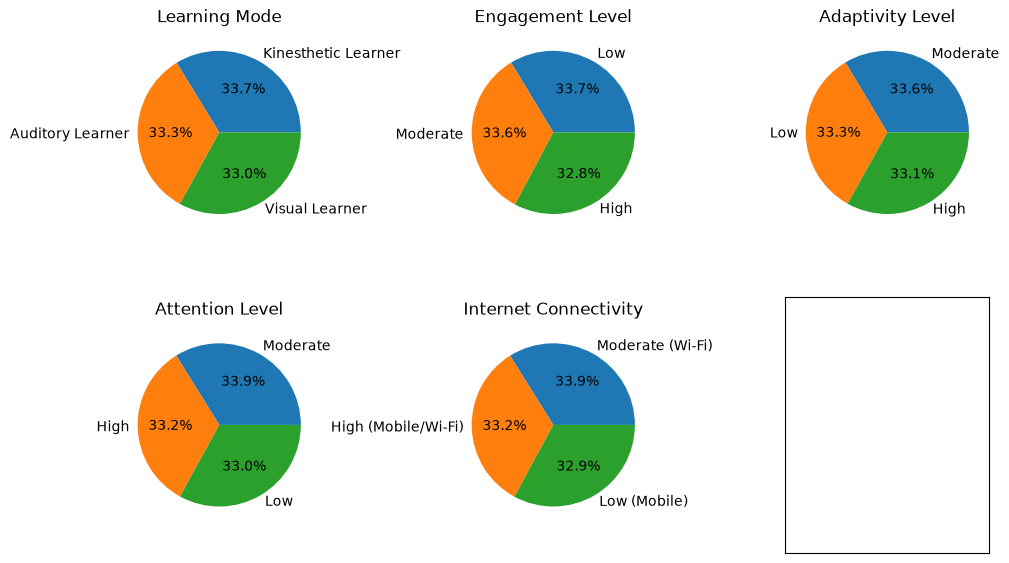

In [24]:
fig, ax = plt.subplots(2,3,figsize=(10,6),sharex=True,sharey=True)

vc = df['Learning Mode Prediction'].value_counts()
ax[0,0].pie(vc,labels=vc.index,autopct="%0.1f%%")
ax[0,0].set_title("Learning Mode")

vc = df['Engagement Level'].value_counts()
ax[0,1].pie(vc,labels=vc.index,autopct="%0.1f%%")
ax[0,1].set_title("Engagement Level")

vc = df['Adaptivity Level'].value_counts()
ax[0,2].pie(vc,labels=vc.index,autopct="%0.1f%%",)
ax[0,2].set_title("Adaptivity Level")

vc = df['Attention Level'].value_counts()
ax[1,0].pie(vc,labels=vc.index,autopct="%0.1f%%",)
ax[1,0].set_title("Attention Level")

vc = df['Internet Connectivity'].value_counts()
ax[1,1].pie(vc,labels=vc.index,autopct="%0.1f%%",)
ax[1,1].set_title("Internet Connectivity")

plt.tight_layout()
plt.show()

<Axes: ylabel='Performance Metrics'>

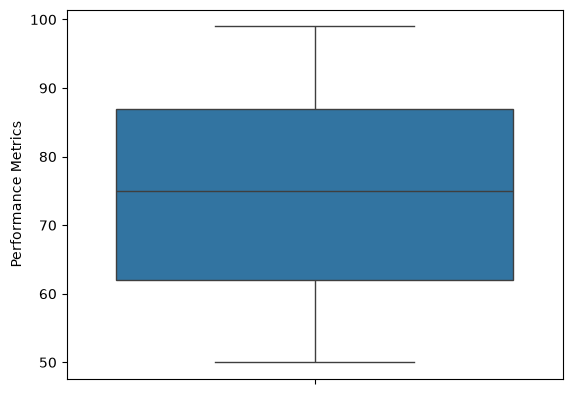

In [33]:
sns.boxplot(data = df['Performance Metrics'])

## 2. Daily Average Engagement and Attention
- #### Objective:
  Track how student attention/engagement varies daily.
- #### Tools:
  pandas, matplotlib.pyplot
- ### Tasks:
    - Group by date and calculate average attention and engagement.
    - Plot line charts for daily trends.

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Session ID                10000 non-null  int64
 1   Date                      10000 non-null  str  
 2   EEG Data (PSD Features)   10000 non-null  str  
 3   Engagement Level          10000 non-null  str  
 4   Attention Level           10000 non-null  str  
 5   Internet Connectivity     10000 non-null  str  
 6   Adaptivity Level          10000 non-null  str  
 7   Learning Mode Prediction  10000 non-null  str  
 8   Performance Metrics       10000 non-null  int64
dtypes: int64(2), str(7)
memory usage: 703.3 KB


### -> converting date columns datatype from str to datetime

In [36]:
df['Date'] = pd.to_datetime(df['Date'])

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Session ID                10000 non-null  int64         
 1   Date                      10000 non-null  datetime64[us]
 2   EEG Data (PSD Features)   10000 non-null  str           
 3   Engagement Level          10000 non-null  str           
 4   Attention Level           10000 non-null  str           
 5   Internet Connectivity     10000 non-null  str           
 6   Adaptivity Level          10000 non-null  str           
 7   Learning Mode Prediction  10000 non-null  str           
 8   Performance Metrics       10000 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(6)
memory usage: 703.3 KB


### -> Encoding the categorical columns : ```{'High': 3, 'Moderate': 2, 'Low': 1}```

In [81]:
mapping = {'High': 3, 'Moderate': 2, 'Low': 1}
df['Engagement Level'] = df['Engagement Level'].map(mapping)
df['Attention Level'] = df['Attention Level'].map(mapping)
df['Attention Level'].astype(int)
df['Engagement Level'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Session ID                10000 non-null  int64         
 1   Date                      10000 non-null  datetime64[us]
 2   EEG Data (PSD Features)   10000 non-null  str           
 3   Engagement Level          10000 non-null  int64         
 4   Attention Level           10000 non-null  int64         
 5   Internet Connectivity     10000 non-null  str           
 6   Adaptivity Level          10000 non-null  str           
 7   Learning Mode Prediction  10000 non-null  str           
 8   Performance Metrics       10000 non-null  int64         
dtypes: datetime64[us](1), int64(4), str(4)
memory usage: 703.3 KB


### -> making new columns from date column

In [120]:
df['Day'] = df['Date'].dt.day
df['Day_name'] = df['Date'].dt.day_name()
df.head()

,Session ID,Date,EEG Data (PSD Features),Engagement Level,Attention Level,Internet Connectivity,Adaptivity Level,Learning Mode Prediction,Performance Metrics,Day,Day_name,
0,183,2025-01-20,"[0.02336871035675725, 0.14892576656473, 0.4845...",3,3,High (Mobile/Wi-Fi),Moderate,Visual Learner,84,20,Monday,0
1,121,2025-01-20,"[0.3587673311624021, 0.8537981137219391, 0.420...",1,3,Moderate (Wi-Fi),High,Auditory Learner,82,20,Monday,0
2,169,2025-01-10,"[0.7420744093003028, 0.9072353407615483, 0.122...",2,3,Low (Mobile),Low,Auditory Learner,83,10,Friday,4
3,132,2025-01-20,"[0.5596059164442914, 0.4645215049524961, 0.062...",3,2,Low (Mobile),Moderate,Visual Learner,66,20,Monday,0
4,190,2025-01-18,"[0.15041646487754368, 0.7331633184349893, 0.86...",3,3,High (Mobile/Wi-Fi),Moderate,Auditory Learner,93,18,Saturday,5


In [95]:
df2 = df.groupby("Day")[['Engagement Level','Attention Level']].mean().reset_index()

In [96]:
df2

,Day,Engagement Level,Attention Level
0,1,2.046053,2.013158
1,2,1.978916,2.024096
2,3,2.003165,1.984177
3,4,1.962162,2.078378
4,5,2.006116,1.932722
5,6,2.008671,1.956647
6,7,1.993506,1.993506
7,8,2.074675,1.964286
8,9,2.023881,1.970149
9,10,1.977778,2.047619


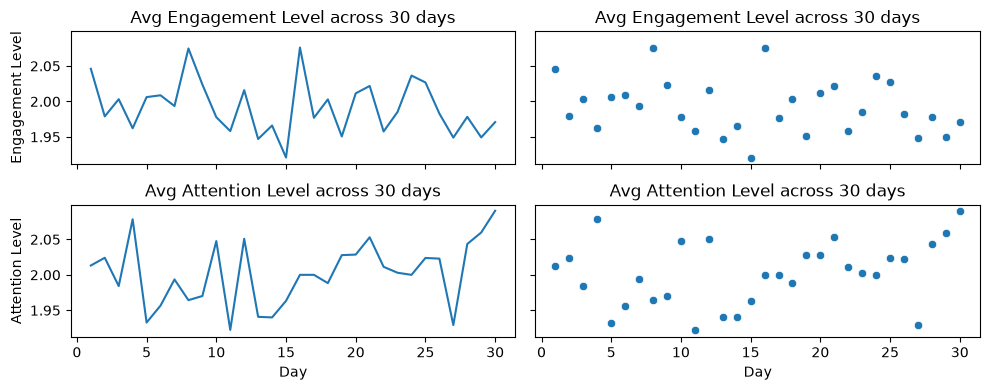

In [110]:
fig, ((ax1,ax2), (ax3,ax4)) = plt.subplots(2,2,figsize=(10,4),sharex=True,sharey=True)
sns.lineplot(data=df2,x="Day",y="Engagement Level",ax=ax1)
ax1.set_title("Avg Engagement Level across 30 days")

sns.lineplot(data=df2,x="Day",y="Attention Level",ax=ax3)
ax3.set_title("Avg Attention Level across 30 days")

sns.scatterplot(data=df2,x="Day",y="Engagement Level",ax=ax2)
ax2.set_title("Avg Engagement Level across 30 days")

sns.scatterplot(data=df2,x="Day",y="Attention Level",ax=ax4)
ax4.set_title("Avg Attention Level across 30 days")

plt.tight_layout()

## 3. Most and Least Engaged Students
- #### Objective:
  Identify students who consistently perform well or poorly.
- #### Tools:
  pandas, numpy, matplotlib
- ### Tasks:
  - Group by student_id and average engagement or attention.
  - Sort and display top/bottom 10 students using a bar chart

<Axes: xlabel='Performance Metrics', ylabel='Density'>

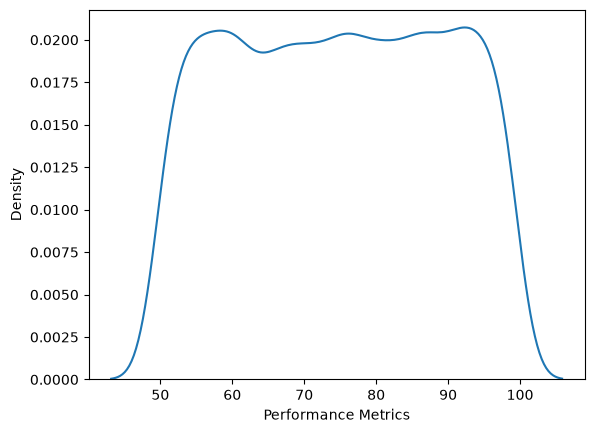

In [113]:
sns.kdeplot(data=df,x='Performance Metrics')

In [138]:
bottom_10 = df.sort_values(by="Performance Metrics")
top_10 = df.sort_values(by="Performance Metrics",ascending=False).head(100)

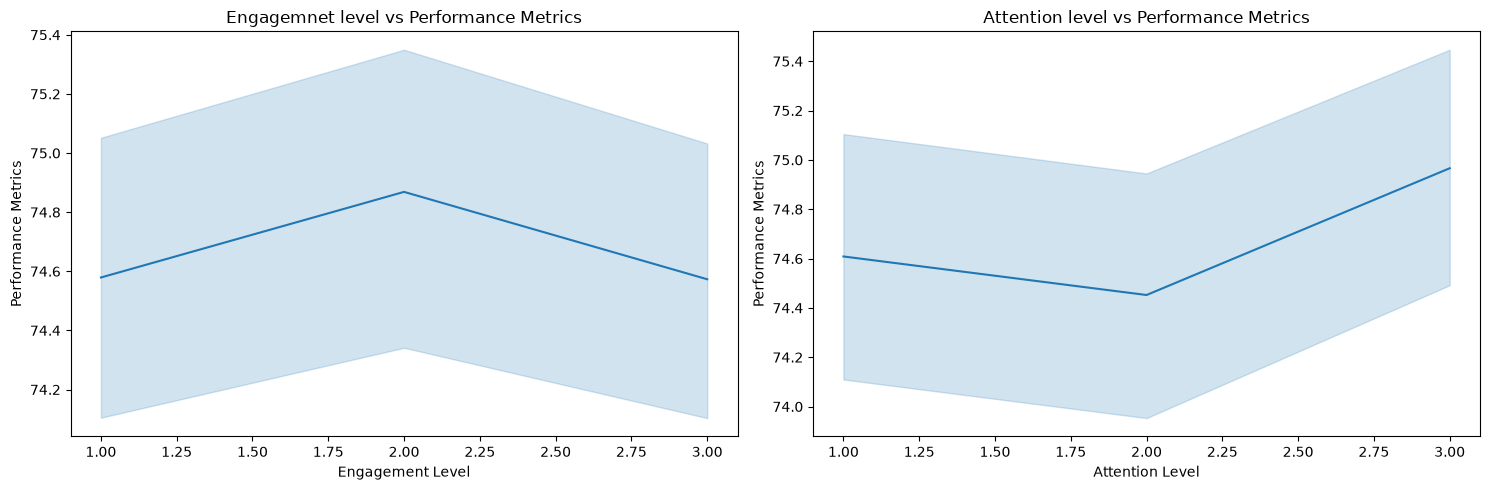

In [153]:
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(15,5))

sns.lineplot(data=df, x="Engagement Level",y="Performance Metrics",ax=ax1,)
sns.lineplot(data=df, x='Attention Level',y="Performance Metrics",ax=ax2,)

ax2.set_title("Attention level vs Performance Metrics")
ax1.set_title("Engagemnet level vs Performance Metrics")

plt.tight_layout()

### 4. Engagement by Learning Mode
- #### Objective:
  Analyze which learning modes lead to higher engagement.
- #### Tools:
  pandas, matplotlib
- ### Tasks:
    - Group by learning_mode and compute average engagement.
    - Plot a bar chart to compare modes.

In [160]:
df3 = df.groupby("Learning Mode Prediction")["Engagement Level"].mean()
df3

Learning Mode Prediction
Auditory Learner       2.015334
Kinesthetic Learner    1.977771
Visual Learner         1.980303
Name: Engagement Level, dtype: float64

<Axes: xlabel='Learning Mode Prediction', ylabel='Engagement Level'>

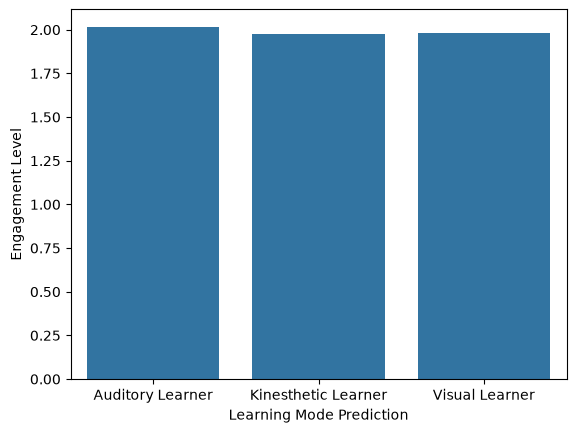

In [161]:
sns.barplot(data=df3)

## Additional Analysis

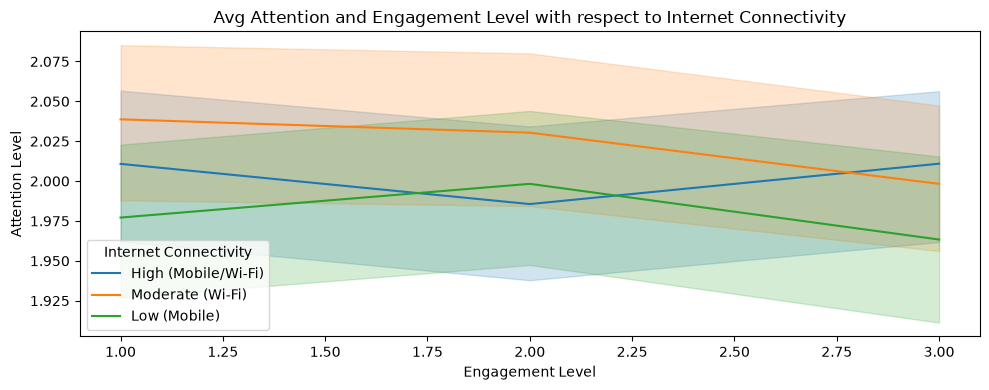

In [165]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df,x="Engagement Level",y="Attention Level",hue="Internet Connectivity")
plt.title("Avg Attention and Engagement Level with respect to Internet Connectivity")
plt.tight_layout()

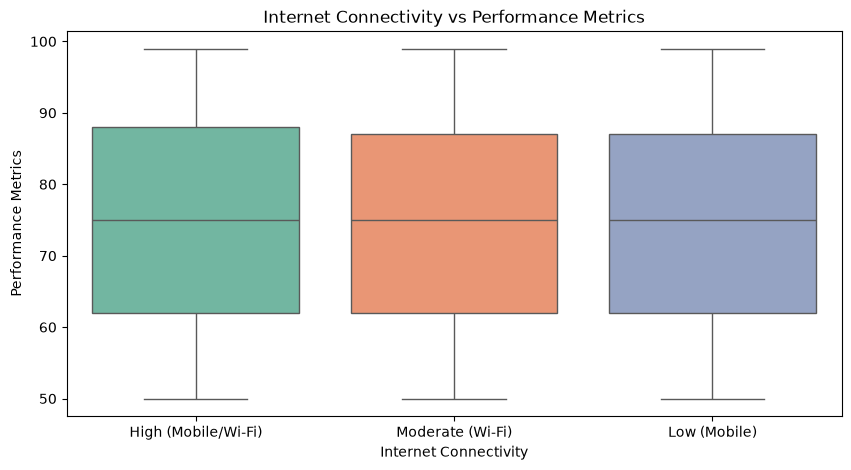

In [169]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Internet Connectivity', y='Performance Metrics',hue='Internet Connectivity' ,palette='Set2')
plt.title("Internet Connectivity vs Performance Metrics")
plt.show()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7280\914458602.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Learning Mode Prediction', y='Performance Metrics', estimator=np.mean, palette='viridis')


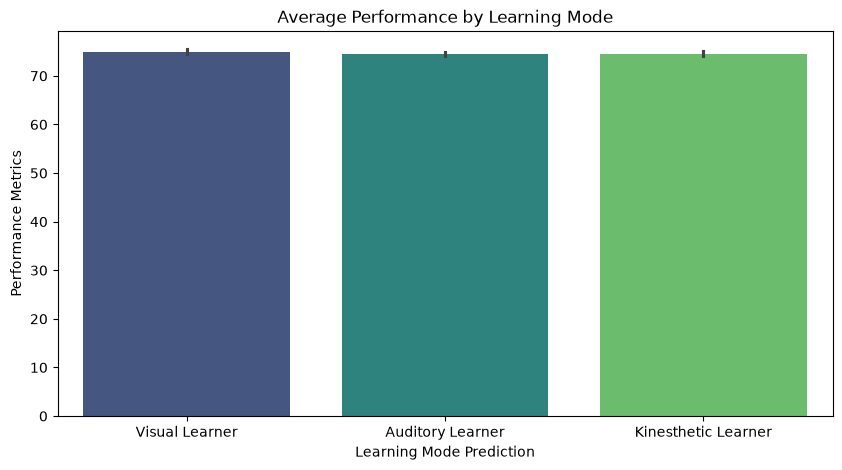

In [170]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='Learning Mode Prediction', y='Performance Metrics', estimator=np.mean, palette='viridis')
plt.title("Average Performance by Learning Mode")
plt.show()

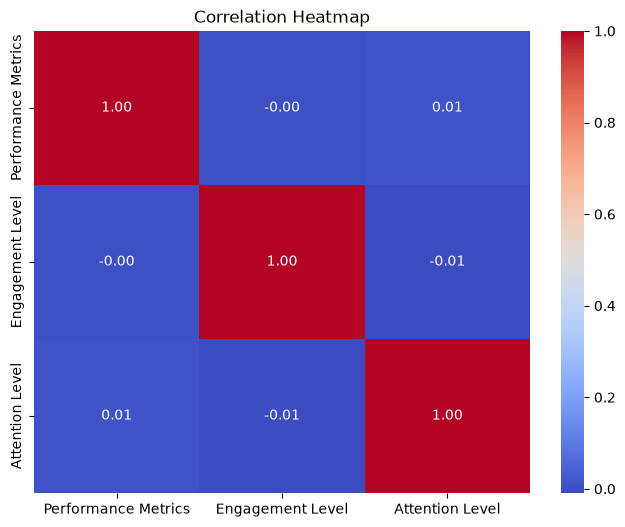

In [171]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Performance Metrics', 'Engagement Level', 'Attention Level']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()